In [1]:
import json
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import StandardScaler

#dane userów
with open('C:\\Users\\julia\\Desktop\\Studia\\2_rok\\mgr\\cresci-stock-2018_tweets.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

#etykiety 
labels_df = pd.read_csv('C:\\Users\\julia\\Desktop\\Studia\\2_rok\\mgr\\cresci-stock-2018.tsv', sep='\t', header=None, names=['id', 'label'])

label_map = {'human': 0, 'bot': 1}
labels_df['target'] = labels_df['label'].map(label_map)

# ekstrakcja danych o użytkowniku
def extract_user_data(record):
    user_info = record['user']
    user_info['created_at_status'] = record.get('created_at')
    return user_info

user_data_list = [extract_user_data(record) for record in raw_data]
df_users = pd.DataFrame(user_data_list)
df_users['id'] = df_users['id'].astype(str)
labels_df['id'] = labels_df['id'].astype(str)
df_merged = df_users.merge(labels_df[['id', 'target']], on='id')



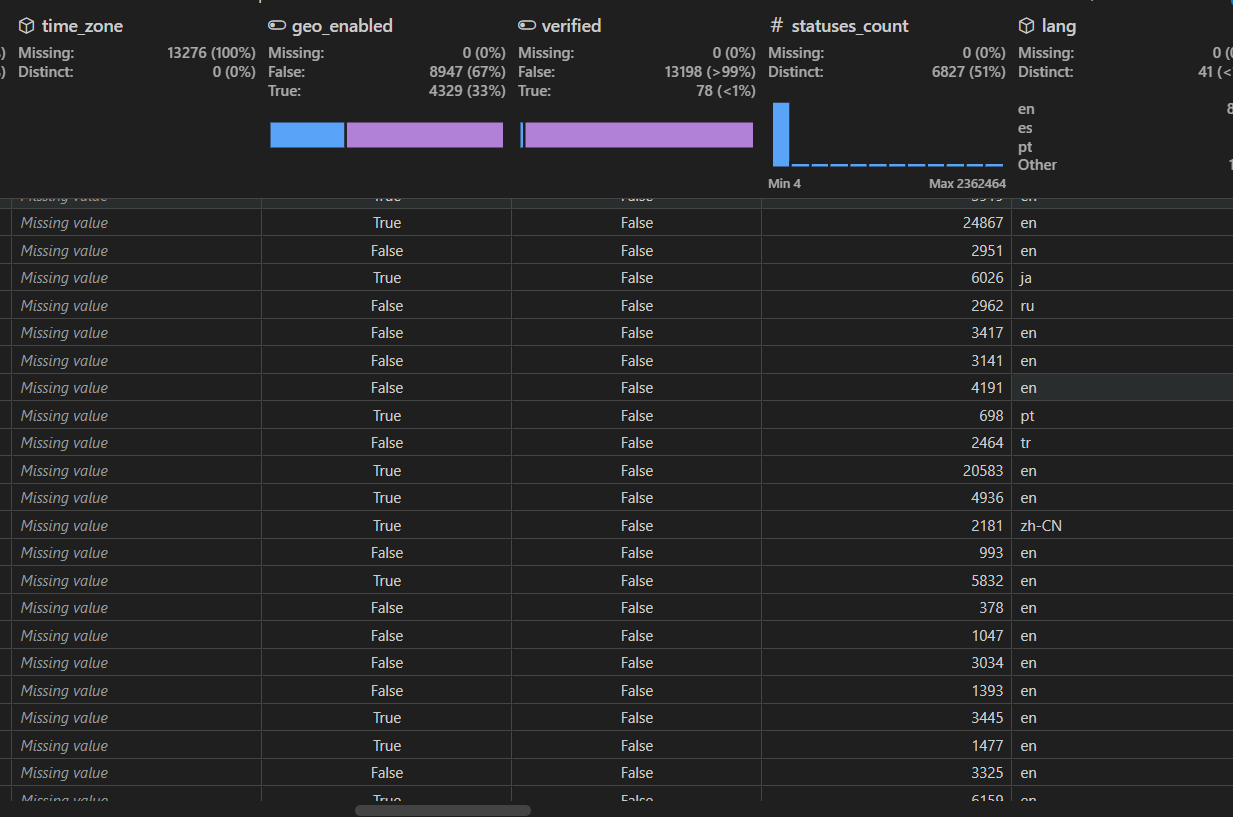

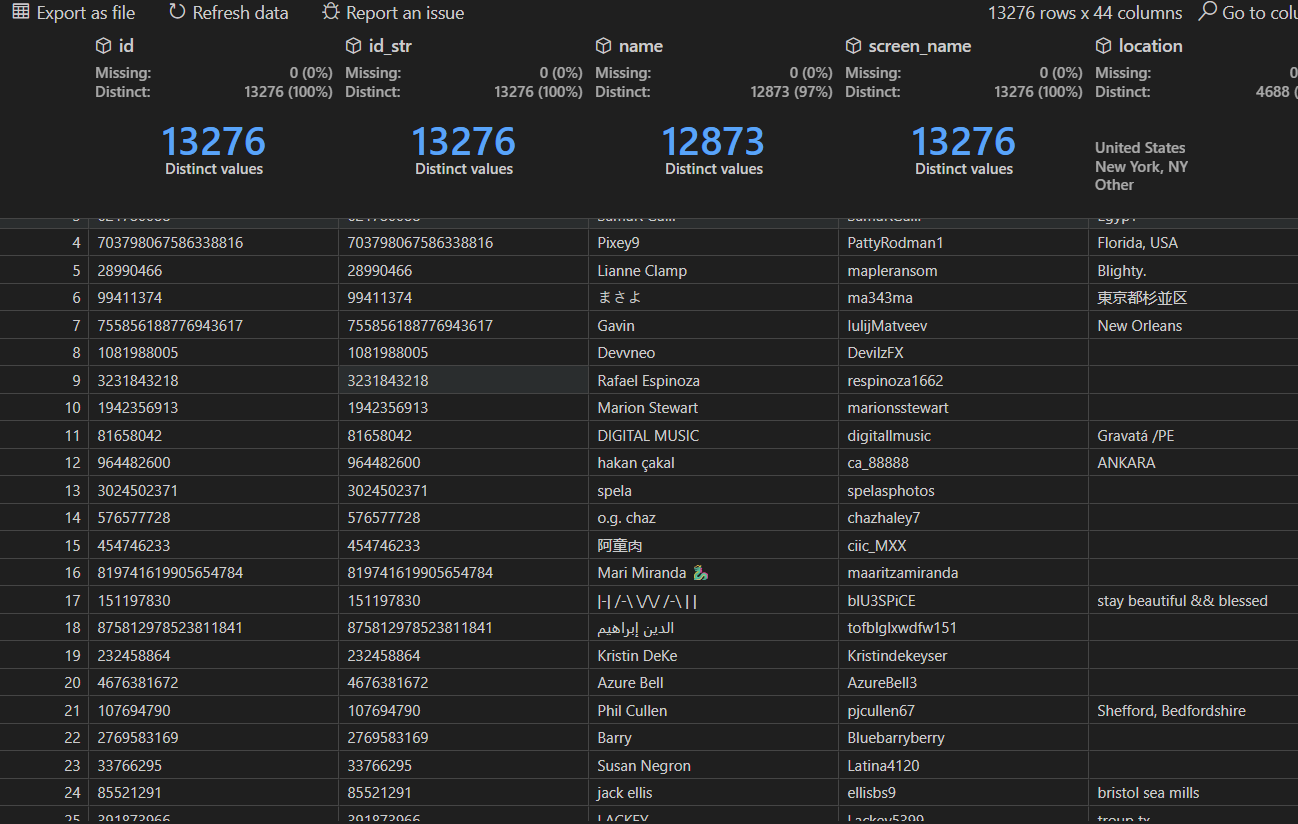

używam rozszerzenia Data Wrangler do przejrzenia dataframe'a w wygodnej formie, sceenshoty są w plikach image.png i image1.png.
Na podstawie podsumowań każdej kolumny od razu wybieram zmienne do usunięcia, które mają za mało distinct wartości (za mala zmienność) albo nie mają sensu do uzycia do ML - np kolumny z ID. 

* do usuniecia po obejrzeniu danych:
* id,
* id_str,
* name,
* screen_name,
* entities (dubluje informacje z kolumny url),
* protected (0 zmiennosci, 100% danych ma False),
* utc_offset (100% missing),
* time_zone (100% missing),
* verified (99% False),
* contributors_enabled (100% false),
* is_translator (100% False),
* is_translation_enabled (99% False),
* profile_image_url,
* profile_image_url_https,
* default_profile_image (99% false),
* following (100% false),
* follow_request_sent (100% false),
* notifications (100% false),
* translator_type (99% none),
* created_at_status


In [2]:
columns_to_drop = [
    'id',
    'id_str',
    'name',
    'screen_name',
    'entities',
    'protected',
    'utc_offset',
    'time_zone',
    'verified',
    'contributors_enabled',
    'is_translator',
    'is_translation_enabled',
    'profile_image_url',
    'profile_image_url_https',
    'profile_background_image_url_https', 
    'default_profile_image',
    'following',
    'follow_request_sent',
    'notifications',
    'translator_type',
    'created_at_status'
]

df_cleaned = df_merged.drop(columns=columns_to_drop, errors='ignore')


In [ ]:
#na pozostałych zmiennych robię odpowiednie przekształcenia
df_cleaned['has_profile_banner'] = df_merged['profile_banner_url'].notnull().astype(int)

df_cleaned['user_created_at'] = pd.to_datetime(df_cleaned['created_at'],errors='coerce').dt.tz_localize(None)
df_cleaned['account_age_days'] = (pd.Timestamp('2019-05-31') - df_cleaned['user_created_at']).dt.days #umowna data 31.05.2019 ponieważ zbieranie danych zakonczono w maju 2019

df_cleaned['has_description'] = df_cleaned['description'].astype(bool).astype(int)

df_cleaned['has_location'] = df_cleaned['location'].str.strip().apply(lambda x: 0 if x == '' else 1)

df_cleaned['has_default_bg_theme'] = df_cleaned['profile_background_image_url'].apply(
    lambda x: 0 if 'theme1/bg.png' in str(x) else 1)

df_cleaned['geo_enabled'] = df_cleaned['geo_enabled'].astype(int)

df_cleaned['profile_background_tile'] = df_cleaned['profile_background_tile'].astype(int)

df_cleaned['profile_use_background_image'] = df_cleaned['profile_use_background_image'].astype(int)

df_cleaned['default_profile'] = df_cleaned['default_profile'].astype(int)

df_cleaned['has_extended_profile'] = df_cleaned['has_extended_profile'].astype(int)

df_cleaned['has_added_url'] = df_cleaned['url'].apply(lambda x: 1 if pd.notna(x) and str(x).strip() != '' else 0) 

#zostawiam tylko kilka najczestszych kategorii wg statystyk z widoku data wrangler, reszta jest bucketowana jako 'other'
top_profile_text_colors = ['333333', '000000']
df_cleaned['profile_text_color_cat'] = df_cleaned['profile_text_color'].apply(
    lambda x: x if x in top_profile_text_colors else 'other'
)

top_sidebar_colors =['DDEEF6', '000000', 'EFEFEF']
df_cleaned['sidebar_fill_color_cat'] = df_cleaned['profile_sidebar_fill_color'].apply(
    lambda x: x if x in top_sidebar_colors else "other"
)

top_sidebar_border_colors = ['C0DEED', 'FFFFFF', '000000']
df_cleaned['sidebar_border_color_cat'] = df_cleaned['profile_sidebar_border_color'].apply(
    lambda x: x if x in top_sidebar_border_colors else "other"
)

top_profile_link_colors = ['1DA1F2', '0084B4'] 
df_cleaned['profile_link_color_cat'] = df_cleaned['profile_link_color'].apply(
    lambda x: x if x in top_profile_link_colors else "other"
)

top_profile_background_colors = ['C0DEED', 'F5F8FA', '000000']
df_cleaned['profile_background_color_cat'] = df_cleaned['profile_background_color'].apply(
    lambda x: x if x in top_profile_background_colors else "other"
)

top_lang = ['en', 'es', 'pt']
df_cleaned['lang_cat'] = df_cleaned['lang'].apply(
    lambda x: x if x in top_lang else "other"
)

#drop kolumn z których byly robione zmienne
df_cleaned = df_cleaned.drop(columns=[
    'description', 
    'profile_banner', 
    'user_created_at',  
    'created_at', 
    'location',
    'url' ,
    'lang',
    'profile_background_image_url', 
    'profile_banner_url', 
    'entities',
    'profile_text_color',
    'profile_sidebar_fill_color',
    'profile_sidebar_border_color',
    'profile_link_color',
    'profile_background_color' 

], errors='ignore')

'''ogladam tak wyczyszczony dataset w Data Wrangler: image2.png i image3.png
generuję raport o statystykach każdej zmiennej i korelajach z biblioteki ydata-profiling. 
Nie uruchamiam tu kodu do generowania, ponieważ biblioteka nie obsługuje Pythona 3.14 którego mam lokalnie,
więc wygenerowałam raport w Google Colab. Jest załączony jako plik html. 

Kod do wygenerowania raportu: 
!pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df_cleaned,
    explorative=True,
    minimal=True,  
    correlations={
        "pearson": {"calculate": True}, 
        "spearman": {"calculate": False},
        "kendall": {"calculate": False},
        "phi_k": {"calculate": True}, 
        "cramers": {"calculate": True} 
    },
    vars={"num": {"low_categorical_threshold": 0}} 
)

profile.to_file("korelacje.html")

from google.colab import files
files.download("korelacje.html")
'''


C:\Users\julia\AppData\Local\Temp\ipykernel_28624\1476371839.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned['user_created_at'] = pd.to_datetime(df_cleaned['created_at'],errors='coerce').dt.tz_localize(None)


'ogladam tak wyczyszczony dataset w Data Wrangler: image2.png i image3.png\ngeneruję raport o statystykach każdej zmiennej i korelajach z biblioteki ydata-profiling. \nNie uruchamiam tu kodu do generowania, ponieważ biblioteka nie obsługuje Pythona 3.14 którego mam lokalnie,\nwięc wygenerowałam raport w Google Colab. Jest załączony jako plik html. \n\nKod do wygenerowania raportu: \n!pip install ydata-profiling\nfrom ydata_profiling import ProfileReport\n\nprofile = ProfileReport(\n    df_cleaned,\n    explorative=True,\n    minimal=True,  \n    correlations={\n        "pearson": {"calculate": True},\n        "spearman": {"calculate": False},\n        "kendall": {"calculate": False},\n        "phi_k": {"calculate": True}, \n        "cramers": {"calculate": True} \n    },\n    vars={"num": {"low_categorical_threshold": 0}} \n)\n\nprofile.to_file("korelacje.html")\n\nfrom google.colab import files\nfiles.download("korelacje.html")\n'

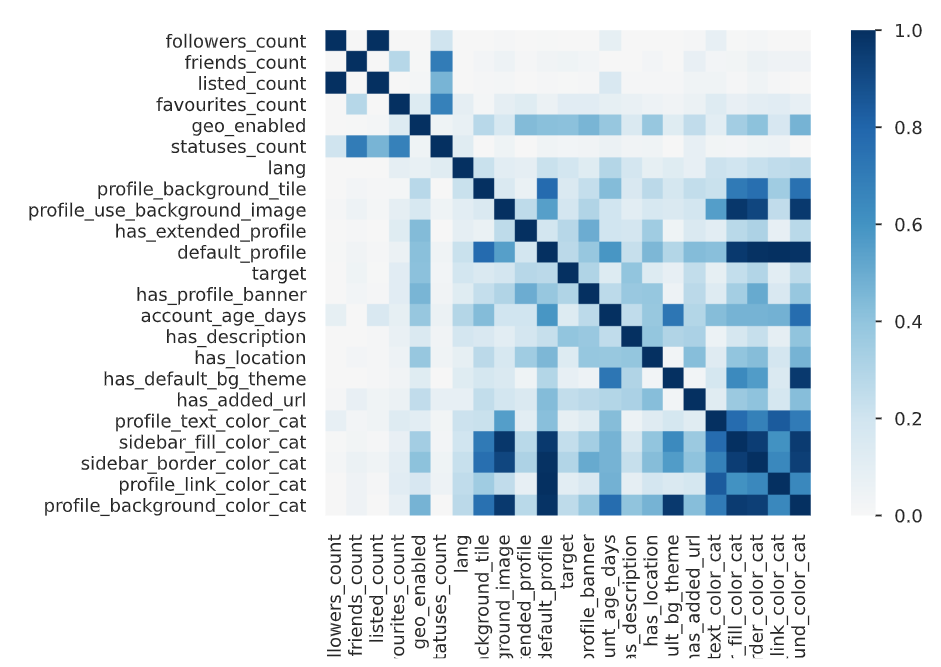

Ponieważ mam różne typy zmiennych i interesuje mnie różny rodzaj korelacji (nie tylko liniowa) oglądam macierz i tabelę statystyki Phik. Większość zmiennych nie jest skorelowana, ale widać mocne korelacje przy zmiennych kategorycznych kolorów profilu. Bardzo wysoka wartość Phik dla par tych zmiennych i zmiennej "default profile". Usunę zmienne mówiące o kolorach elementow profilu, a zostawię zmienną default profile, bo jest najbardziej ogólna. 

In [4]:
#drop kolumn z za wysoka korelacja
df_cleaned = df_cleaned.drop(columns=[
'profile_text_color_cat',
'sidebar_fill_color_cat',
'sidebar_border_color_cat',
'profile_link_color_cat',
'profile_background_color_cat'

], errors='ignore')

count    13276.000000
mean      2400.580747
std        976.734411
min        633.000000
25%       1588.750000
50%       2603.000000
75%       3176.000000
max       4712.000000
Name: account_age_days, dtype: float64


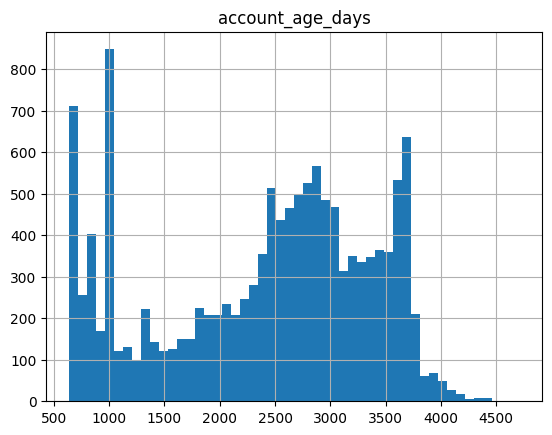

count    1.327600e+04
mean     2.739882e+03
std      1.392792e+05
min      0.000000e+00
25%      1.000000e+01
50%      3.900000e+01
75%      2.402500e+02
max      1.535081e+07
Name: followers_count, dtype: float64


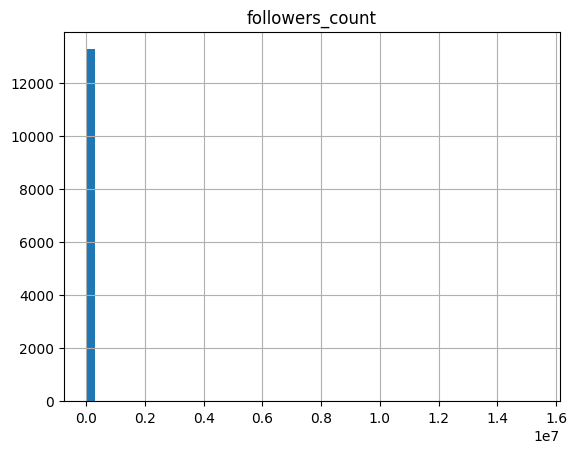

count     13276.000000
mean        408.429497
std        2903.382489
min           0.000000
25%           0.000000
50%          53.000000
75%         306.000000
max      181489.000000
Name: friends_count, dtype: float64


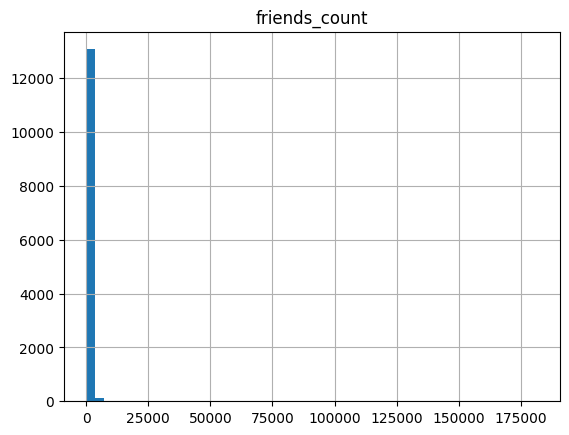

count    13276.000000
mean        32.441925
std        644.750056
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max      57040.000000
Name: listed_count, dtype: float64


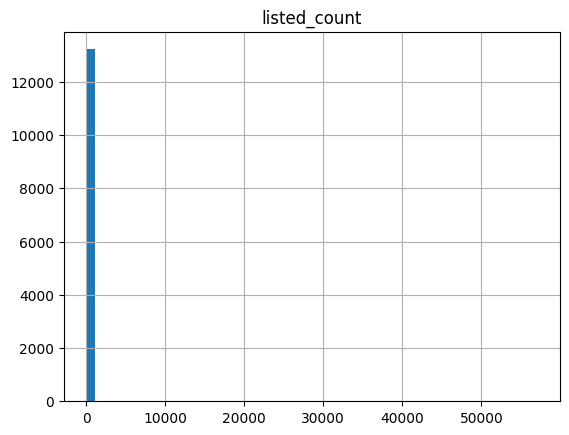

count    1.327600e+04
mean     1.009116e+04
std      4.566432e+04
min      4.000000e+00
25%      1.008750e+03
50%      2.525000e+03
75%      4.869250e+03
max      2.362464e+06
Name: statuses_count, dtype: float64


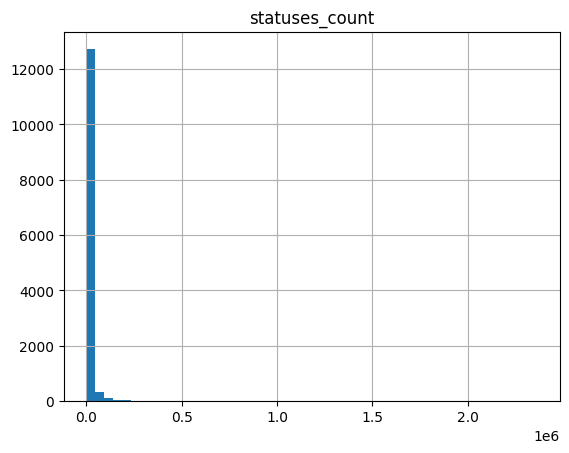

count     13276.000000
mean       5876.983278
std       19040.902917
min           0.000000
25%         566.750000
50%        1640.000000
75%        2608.250000
max      572806.000000
Name: favourites_count, dtype: float64


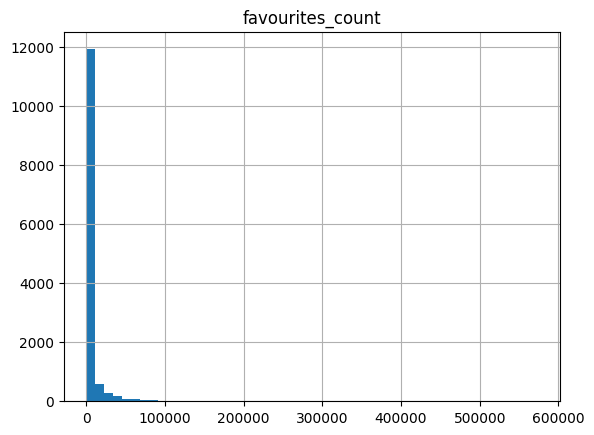

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['account_age_days', 'followers_count', 'friends_count', 'listed_count', 'statuses_count', 'favourites_count']:
    print(df_cleaned[col].describe())
    plt.title(col)
    df_cleaned[col].hist(bins=50)
    plt.show()



problem long tails, ale modele drzewiaste powinny sobie poradzic. Nie wykonuję na razie również np standaryzacji, bo skupiam się na modelach drzewiastych.

In [6]:
#Eksperymentuję z feature engineeringiem: 
df_cleaned['followers_friends_ratio'] = df_cleaned['followers_count'] / (df_cleaned['friends_count'] + 1)

df_cleaned['tweets_per_day'] = df_cleaned['statuses_count'] / (df_cleaned['account_age_days'] + 1)

df_cleaned['favourites_per_day'] = df_cleaned['favourites_count'] / (df_cleaned['account_age_days'] + 1)

In [7]:
#OHE na zmienej kategorialnej lang_cat - wcześniej mniejsze kategorie wrzuciłam do 'other'
df_cleaned = pd.get_dummies(df_cleaned, columns=['lang_cat'], prefix='lang')

In [ ]:
#train test split - moje klasy są już zbalansowane (47%/53% więc nie robiłam downsamplingu ani oversamplingu)
X = df_cleaned.drop(columns=['target'])
y = df_cleaned['target']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import make_pipeline

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42), #jako baseline, żeby zobaczyć jak dobrą predykcję zrobi płytkie pojedyncze drzewo i móc porównać do tego złożone modele
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    print(f"\n{name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))



Decision Tree
              precision    recall  f1-score   support

           0       0.87      0.76      0.81      1235
           1       0.81      0.90      0.86      1421

    accuracy                           0.84      2656
   macro avg       0.84      0.83      0.83      2656
weighted avg       0.84      0.84      0.84      2656

ROC AUC: 0.9014946422517073

Random Forest
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      1235
           1       0.89      0.89      0.89      1421

    accuracy                           0.88      2656
   macro avg       0.88      0.88      0.88      2656
weighted avg       0.88      0.88      0.88      2656

ROC AUC: 0.9487283004783652

XGBoost
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1235
           1       0.89      0.89      0.89      1421

    accuracy                           0.88      2656
   macro avg       0.88      0.88

c:\Users\julia\Desktop\Studia\2_rok\mgr\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:08:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [10]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print("Random Forest best params:", grid_search_rf.best_params_)
print("Random Forest best CV ROC AUC:", grid_search_rf.best_score_)

#ewaluacja na zbiorze testowym (np. dla RF z najlepszymi parametrami)
best_rf = grid_search_rf.best_estimator_
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]
roc_auc_test_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Random Forest test ROC AUC: {roc_auc_test_rf:.4f}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Random Forest best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Random Forest best CV ROC AUC: 0.943417880298067
Random Forest test ROC AUC: 0.9485


In [12]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train)

print("XGBoost best params:", grid_search_xgb.best_params_)
print("XGBoost best CV ROC AUC:", grid_search_xgb.best_score_)

best_xgb = grid_search_xgb.best_estimator_
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
roc_auc_test_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost test ROC AUC: {roc_auc_test_xgb:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
XGBoost best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
XGBoost best CV ROC AUC: 0.9446476203285957
XGBoost test ROC AUC: 0.9517


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve - {model_name}")
    plt.show()

--- Decision Tree ---
Accuracy:  0.8373
Precision: 0.8136
Recall:    0.9029
F1-score:  0.8559
ROC AUC:   0.9015

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.76      0.81      1235
           1       0.81      0.90      0.86      1421

    accuracy                           0.84      2656
   macro avg       0.84      0.83      0.83      2656
weighted avg       0.84      0.84      0.84      2656

Confusion Matrix:
[[ 941  294]
 [ 138 1283]]


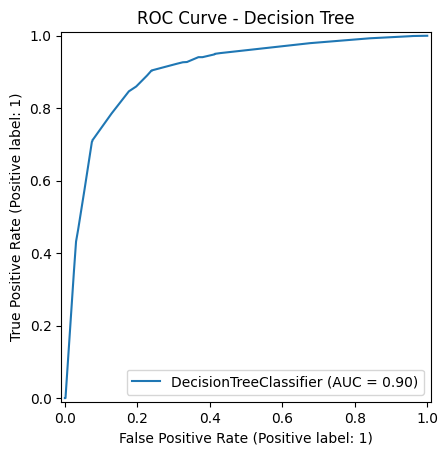

--- Random Forest ---
Accuracy:  0.8874
Precision: 0.8951
Recall:    0.8944
F1-score:  0.8948
ROC AUC:   0.9485

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      1235
           1       0.90      0.89      0.89      1421

    accuracy                           0.89      2656
   macro avg       0.89      0.89      0.89      2656
weighted avg       0.89      0.89      0.89      2656

Confusion Matrix:
[[1086  149]
 [ 150 1271]]


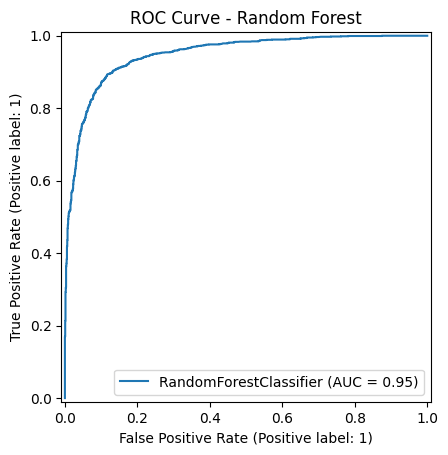

--- XGBoost ---
Accuracy:  0.8825
Precision: 0.8891
Recall:    0.8916
F1-score:  0.8904
ROC AUC:   0.9517

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1235
           1       0.89      0.89      0.89      1421

    accuracy                           0.88      2656
   macro avg       0.88      0.88      0.88      2656
weighted avg       0.88      0.88      0.88      2656

Confusion Matrix:
[[1077  158]
 [ 154 1267]]


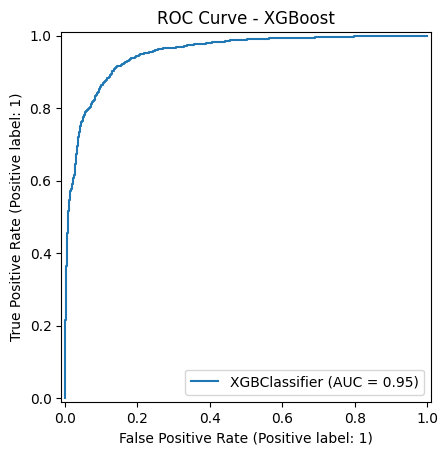

In [ ]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

evaluate_model(dt, X_test, y_test, "Decision Tree")
evaluate_model(best_rf, X_test, y_test, "Random Forest")
evaluate_model(best_xgb, X_test, y_test, "XGBoost")

Minimalna poprawa po grid searchu. Można rozważyć rozszerzenie zestawu parametrów do tuningu, RandomizedSearch. Ale może to nie przynieść dużych zysków w jakości modeli. Ale obecne wyniki są bardzo zadowalające.